# player_level_data

In [1]:
import pandas as pd

# Load the datasets
players_stats = pd.read_csv('player_level_data/M/players_stats.csv')
teams_ids = pd.read_csv('player_level_data/M/teams_ids.csv')
tournaments_stages_matches = pd.read_csv('player_level_data/M/tournaments_stages_matches_games_ids.csv')
player_ids = pd.read_csv('player_level_data/M/player_ids.csv')

# Step 1: Rename columns for consistency
players_stats.rename(columns={"Teams": "Team", "Player": "Player Name"}, inplace=True)
teams_ids.rename(columns={"Team": "Team Name"}, inplace=True)
player_ids.rename(columns={"Player": "Player Name"}, inplace=True)

# Step 2: Merge Player Stats with Player IDs
players_stats_merged = pd.merge(players_stats, player_ids, on="Player Name", how="left")

# Step 3: Merge with Team IDs
players_stats_merged = pd.merge(players_stats_merged, teams_ids, left_on="Team", right_on="Team Name", how="left")

# Step 4: Merge with Match Information using "Match Type"
players_stats_merged = pd.merge(players_stats_merged, tournaments_stages_matches, on="Match Type", how="left")

# Step 5: Select and rename relevant columns
final_player_data = players_stats_merged[[
    "Match ID", "Player ID", "Team ID", "Agents", "Kills", "Deaths", "Assists",
    "First Kills", "Average Combat Score", "Headshot %"
]].rename(columns={
    "Agents": "Agent",
    "First Kills": "First_Bloods",
    "Average Combat Score": "ACS",
    "Headshot %": "Headshot_Percentage"
})

# Step 6: Process the Agent column to retain only the first agent in cases of multiple agents
final_player_data["Agent"] = final_player_data["Agent"].apply(lambda x: x.split(',')[0].strip() if isinstance(x, str) else x)

# Step 7: Clean and reformat the data
# Convert percentage columns to float (removing % sign)
final_player_data["Headshot_Percentage"] = final_player_data["Headshot_Percentage"].str.rstrip('%').astype(float)

# Remove duplicates and rows with missing Match ID or Player ID
final_player_data = final_player_data.drop_duplicates().dropna(subset=["Match ID", "Player ID"])

# # Save the final dataset
# output_path = 'new/player_level_data.csv'
# final_player_data.to_csv(output_path, index=False)

# print(f"Cleaned dataset saved at: {output_path}")

final_player_data


,Match ID,Player ID,Team ID,Agent,Kills,Deaths,Assists,First_Bloods,ACS,Headshot_Percentage
0,235363.0,9558,7035.0,cypher,16,16,7,3,209.0,21.0
3,235364.0,9558,7035.0,cypher,16,16,7,3,209.0,21.0
6,235566.0,9558,7035.0,cypher,16,16,7,3,209.0,21.0
8,235567.0,9558,7035.0,cypher,16,16,7,3,209.0,21.0
11,235568.0,9558,7035.0,cypher,16,16,7,3,209.0,21.0
...,...,...,...,...,...,...,...,...,...,...
1747061,378672.0,301,12694.0,raze,64,44,14,7,290.0,23.0
1747063,295619.0,301,12694.0,raze,64,44,14,7,290.0,23.0
1747065,298699.0,301,12694.0,raze,64,44,14,7,290.0,23.0
1747067,297416.0,301,12694.0,raze,64,44,14,7,290.0,23.0


In [2]:
# pip install ctgan

#  Generate synthetic data using CTGAN

In [3]:
import pandas as pd
from ctgan import CTGAN

# Load the uploaded data
data = pd.read_csv('new/player_level_data.csv')


# Step 1: Preprocess 'Headshot %' column
data['Headshot_Percentage'] = data['Headshot_Percentage']

# Step 2: Remove duplicates
data.drop_duplicates(inplace=True)

# Step 3: Limit Kills and Deaths to maximum thresholds
data.loc[data['Kills'] > 52, 'Kills'] = 52
data.loc[data['Deaths'] > 36, 'Deaths'] = 36

# Step 4: Separate original columns to retain
original_columns = ['Match ID', 'Player ID', 'Team ID', 'Agent']
original_data = data[original_columns].dropna()  # Drop rows with NaN values

# Select columns for synthetic data generation
columns_to_synthesize = ['Kills', 'Deaths', 'Assists', 'First_Bloods', 'ACS', 'Headshot_Percentage']
training_data = data[columns_to_synthesize].dropna().sample(n=3000, random_state=42)

# Initialize and train the CTGAN model with the specified constraints
ctgan = CTGAN(epochs=150)
ctgan.fit(training_data, columns_to_synthesize)

# Generate synthetic data and apply limits for consistency
synthetic_data = ctgan.sample(len(original_data))
synthetic_data.columns = columns_to_synthesize
synthetic_data['Kills'] = synthetic_data['Kills'].clip(upper=52)
synthetic_data['Deaths'] = synthetic_data['Deaths'].clip(upper=36)

# Ensure synthetic data reflects professional game dynamics: more Kills/Assists = higher Average Combat Score
synthetic_data['ACS'] = synthetic_data['Kills'] * 10 + synthetic_data['Assists'] * 5

# Step 5: Combine original and synthetic data
final_data = pd.concat([original_data.reset_index(drop=True), synthetic_data], axis=1)


final_data

,Match ID,Player ID,Team ID,Agent,Kills,Deaths,Assists,First_Bloods,ACS,Headshot_Percentage
0,235363.0,9558,7035.0,cypher,13,17,29,1,275,27.0
1,235364.0,9558,7035.0,cypher,43,15,22,5,540,27.0
2,235566.0,9558,7035.0,cypher,45,14,25,3,575,30.0
3,235567.0,9558,7035.0,cypher,52,36,18,26,610,17.0
4,235568.0,9558,7035.0,cypher,52,34,9,8,565,37.0
...,...,...,...,...,...,...,...,...,...,...
689895,378672.0,301,12694.0,raze,34,36,5,5,365,35.0
689896,295619.0,301,12694.0,raze,12,12,4,1,140,36.0
689897,298699.0,301,12694.0,raze,11,15,7,1,145,30.0
689898,297416.0,301,12694.0,raze,36,29,1,1,365,27.0


In [5]:
# Save the combined data to a CSV file
final_data.to_csv('new/player_level_data_main_syn.csv', index=False)
print("Final combined synthetic data saved as 'final_synthetic_player_level_data.csv'")

Final combined synthetic data saved as 'final_synthetic_player_level_data.csv'


# Map Performance And Team Data

In [6]:
import pandas as pd

# File paths for datasets
maps_stats_path = 'map_performance/M/maps_stats.csv'
teams_picked_agents_path = 'map_performance/M/teams_picked_agents.csv'
agents_pick_rates_path = 'map_performance/M/agents_pick_rates.csv'
teams_ids_path = 'map_performance/M/teams_ids.csv'
tournaments_path = 'map_performance/M/tournaments_stages_matches_games_ids.csv'

# Step 1: Load the datasets
maps_stats = pd.read_csv(maps_stats_path)
teams_picked_agents = pd.read_csv(teams_picked_agents_path)
agents_pick_rates = pd.read_csv(agents_pick_rates_path)
teams_ids = pd.read_csv(teams_ids_path)
tournaments_stages_matches = pd.read_csv(tournaments_path)

# Step 2: Clean and Standardize Datasets

# Clean maps_stats
maps_stats = maps_stats.rename(columns={
    "Total Maps Played": "total_maps_played",
    "Attacker Side Win Percentage": "attacker_win_pct",
    "Defender Side Win Percentage": "defender_win_pct"
})
maps_stats["attacker_win_pct"] = maps_stats["attacker_win_pct"].str.rstrip('%').astype(float)
maps_stats["defender_win_pct"] = maps_stats["defender_win_pct"].str.rstrip('%').astype(float)

# Clean teams_picked_agents
teams_picked_agents = teams_picked_agents.rename(columns={
    "Total Wins By Map": "wins_by_map",
    "Total Loss By Map": "loss_by_map",
    "Total Maps Played": "maps_played"
})

# Clean agents_pick_rates
agents_pick_rates = agents_pick_rates.rename(columns={
    "Pick Rate": "pick_rate"
})
agents_pick_rates["pick_rate"] = agents_pick_rates["pick_rate"].str.rstrip('%').astype(float)

# Ensure consistency in teams_ids
teams_ids.rename(columns={"Team": "team"}, inplace=True)

# Step 3: Merge Datasets

# Merge teams_picked_agents with maps_stats
merged_maps_agents = pd.merge(
    teams_picked_agents, maps_stats,
    on=["Tournament", "Stage", "Match Type", "Map"],
    how="left"
)

# Merge with teams_ids to link Team ID
merged_with_team_ids = pd.merge(
    merged_maps_agents, teams_ids,
    left_on="Team", right_on="team",
    how="left"
).drop(columns=["team"])

# Merge with agents_pick_rates to include pick_rate
merged_with_pick_rates = pd.merge(
    merged_with_team_ids, agents_pick_rates,
    on=["Tournament", "Stage", "Match Type", "Map", "Agent"],
    how="left"
)

# Add Match ID from tournaments_stages_matches
final_merged_data = pd.merge(
    merged_with_pick_rates, tournaments_stages_matches,
    on=["Tournament", "Stage", "Match Type", "Map"],
    how="left"
)

# Step 4: Feature Engineering

# Calculate Win Rate
final_merged_data["win_rate"] = final_merged_data["wins_by_map"] / final_merged_data["maps_played"]

# Calculate Side Advantage
final_merged_data["side_advantage"] = final_merged_data["attacker_win_pct"] - final_merged_data["defender_win_pct"]

# Normalize Pick Rate (per Tournament-Map combination)
final_merged_data["normalized_pick_rate"] = final_merged_data.groupby(["Tournament", "Map"])["pick_rate"].transform(lambda x: x / x.sum())

# Select and arrange relevant columns
final_dataset = final_merged_data[[
    "Match ID", "Tournament", "Stage", "Map", "Team", "Team ID",
    "maps_played", "wins_by_map", "loss_by_map", "total_maps_played",
    "attacker_win_pct", "defender_win_pct", "win_rate", "side_advantage", "normalized_pick_rate"
]]

# Step 5: Remove null values and duplicates
final_dataset = final_dataset.dropna().drop_duplicates()


final_dataset

,Match ID,Tournament,Stage,Map,Team,Team ID,maps_played,wins_by_map,loss_by_map,total_maps_played,attacker_win_pct,defender_win_pct,win_rate,side_advantage,normalized_pick_rate
0,235363.0,Champions Tour 2023: EMEA Last Chance Qualifier,Playoffs,Fracture,Team Heretics,1001,1,0,1,1,71.0,29.0,0.0,42.0,0.021277
1,235363.0,Champions Tour 2023: EMEA Last Chance Qualifier,Playoffs,Fracture,Team Heretics,1001,1,0,1,1,71.0,29.0,0.0,42.0,0.042553
5,235363.0,Champions Tour 2023: EMEA Last Chance Qualifier,Playoffs,Fracture,KOI,7035,1,1,0,1,71.0,29.0,1.0,42.0,0.042553
7,235363.0,Champions Tour 2023: EMEA Last Chance Qualifier,Playoffs,Fracture,KOI,7035,1,1,0,1,71.0,29.0,1.0,42.0,0.021277
10,235363.0,Champions Tour 2023: EMEA Last Chance Qualifier,Playoffs,Pearl,Team Heretics,1001,1,1,0,1,26.0,74.0,1.0,-48.0,0.018149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46869,296749.0,Champions Tour 2024: Pacific Kickoff,Group Stage,Breeze,Rex Regum Qeon,878,1,1,0,1,70.0,30.0,1.0,40.0,0.004823
46872,296749.0,Champions Tour 2024: Pacific Kickoff,Group Stage,Icebox,Gen.G,17,1,1,0,1,63.0,38.0,1.0,25.0,0.010530
46876,296749.0,Champions Tour 2024: Pacific Kickoff,Group Stage,Icebox,Gen.G,17,1,1,0,1,63.0,38.0,1.0,25.0,0.005265
46877,296749.0,Champions Tour 2024: Pacific Kickoff,Group Stage,Icebox,Rex Regum Qeon,878,1,0,1,1,63.0,38.0,0.0,25.0,0.010530


In [7]:
# Step 6: Save the final dataset
output_path = 'new/map_performance_team_data.csv'
final_dataset.to_csv(output_path, index=False)

print(f"Optimized dataset saved at: {output_path}")

Optimized dataset saved at: new/map_performance_team_data.csv


# synthetic_odd_data

In [8]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

# Load the datasets
tournaments_stages_matches_games_ids = pd.read_csv('valo_data1/tournaments_stages_matches_games_ids.csv')
teams_ids = pd.read_csv('valo_data1/teams_ids.csv')

#Split the 'Match Name' column to extract 'Team_A' and 'Team_B'
tournaments_stages_matches_games_ids[['Team_A', 'Team_B']] = tournaments_stages_matches_games_ids['Match Name'].str.split(' vs ', expand=True)

#  Merge to get Team_A_ID and Team_B_ID
synthetic_dataset = tournaments_stages_matches_games_ids.merge(
    teams_ids, how='left', left_on='Team_A', right_on='Team'
).rename(columns={'Team ID': 'Team_A_ID'}).drop(columns=['Team'])

synthetic_dataset = synthetic_dataset.merge(
    teams_ids, how='left', left_on='Team_B', right_on='Team'
).rename(columns={'Team ID': 'Team_B_ID'}).drop(columns=['Team'])

 #Generate Implied Probabilities using GMM
np.random.seed(42)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(np.array([0.35, 0.5, 0.65]).reshape(-1, 1))  # Adjusted range for a realistic spread

# Generate probabilities for Team A with randomness
implied_probs_a = gmm.sample(len(synthetic_dataset))[0].flatten()
synthetic_dataset['Implied_Prob_A'] = np.clip(implied_probs_a + np.random.normal(0, 0.02, len(implied_probs_a)), 0.35, 0.65)
synthetic_dataset['Implied_Prob_B'] = np.clip(1 - synthetic_dataset['Implied_Prob_A'] + np.random.normal(0, 0.02, len(implied_probs_a)), 0.35, 0.65)

# Step 4: Calculate Simulated Odds with Added Variability on both A and B odds
random_adjustment_a = np.random.normal(1.0, 0.05, size=len(synthetic_dataset))
random_adjustment_b = np.random.normal(1.0, 0.05, size=len(synthetic_dataset))

synthetic_dataset['Simulated_Odds_A'] = np.clip(1 / synthetic_dataset['Implied_Prob_A'] * random_adjustment_a, 1, 10)
synthetic_dataset['Simulated_Odds_B'] = np.clip(1 / synthetic_dataset['Implied_Prob_B'] * random_adjustment_b, 1, 10)

# Step 5: Remove duplicate Match IDs and select relevant columns for the final dataset
synthetic_dataset_cleaned = synthetic_dataset.drop_duplicates(subset=['Match ID'])
final_synthetic_dataset = synthetic_dataset_cleaned[[
    'Match ID', 'Match Name', 'Team_A', 'Team_A_ID', 'Team_B', 'Team_B_ID', 
    'Implied_Prob_A', 'Implied_Prob_B', 'Simulated_Odds_A', 'Simulated_Odds_B'
]]

final_synthetic_dataset




C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Match ID,Match Name,Team_A,Team_A_ID,Team_B,Team_B_ID,Implied_Prob_A,Implied_Prob_B,Simulated_Odds_A,Simulated_Odds_B
0,247100,Team Liquid vs Natus Vincere,Team Liquid,474,Natus Vincere,4915,0.483578,0.569309,2.082384,1.720461
2,247101,DRX vs LOUD,DRX,8185,LOUD,6961,0.420414,0.584661,2.213269,1.811065
5,247087,FUT Esports vs T1,FUT Esports,1184,T1,14,0.477948,0.524012,1.937772,1.873907
7,247086,Evil Geniuses vs FunPlus Phoenix,Evil Geniuses,5248,FunPlus Phoenix,11328,0.481102,0.511065,2.202433,1.934132
9,247102,Natus Vincere vs DRX,Natus Vincere,4915,DRX,8185,0.400931,0.592205,2.524499,1.810348
...,...,...,...,...,...,...,...,...,...,...
1922,297253,ZETA DIVISION vs Team Secret,ZETA DIVISION,5448,Team Secret,6199,0.630619,0.350000,1.456858,3.091030
1924,297255,Gen.G vs ZETA DIVISION,Gen.G,17,ZETA DIVISION,5448,0.650000,0.350000,1.561343,2.673486
1926,297256,T1 vs Paper Rex,T1,14,Paper Rex,624,0.600495,0.390466,1.641575,2.608762
1928,297257,DRX vs Gen.G,DRX,8185,Gen.G,17,0.650000,0.350000,1.776792,3.077534


In [9]:
# Save the final dataset to CSV
output_path = 'new/synthetic_odd_data.csv'
final_synthetic_dataset.to_csv(output_path, index=False)

print(f"Final synthetic dataset saved to {output_path}")


Final synthetic dataset saved to new/synthetic_odd_data.csv


# match_data using RF

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Load the datasets
tournaments_stages_matches = pd.read_csv('valo_data1/tournaments_stages_matches_games_ids.csv')
simulated_odds = pd.read_csv('new/synthetic_odd_data.csv')

# Merge the datasets on 'Match ID'
merged_data = pd.merge(tournaments_stages_matches, simulated_odds, on='Match ID')

# Define the winner based on the simulated odds
merged_data['Simulated_Winner'] = merged_data.apply(
    lambda row: 'Team_A' if row['Simulated_Odds_A'] < row['Simulated_Odds_B'] else 'Team_B', axis=1
)

# Prepare data for modeling
X = merged_data[['Simulated_Odds_A', 'Simulated_Odds_B', 'Implied_Prob_A', 'Implied_Prob_B']]
y = merged_data['Simulated_Winner'].apply(lambda x: 1 if x == 'Team_A' else 0)  # Convert to binary

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Generate synthetic outcomes for the entire dataset
merged_data['Predicted_Team_A_Win'] = rf_model.predict(X)
merged_data['Predicted_Winner'] = merged_data['Predicted_Team_A_Win'].apply(lambda x: 'Team_A' if x == 1 else 'Team_B')




Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       319
           1       1.00      1.00      1.00       262

    accuracy                           1.00       581
   macro avg       1.00      1.00      1.00       581
weighted avg       1.00      1.00      1.00       581



In [11]:
# Prepare the final dataset with necessary columns, remove Team_A_Win and convert "Winner" to binary
synthetic_m = merged_data[['Match ID', 'Stage', 'Team_A', 'Team_B', 
                           'Map', 'Tournament', 'Simulated_Odds_A', 'Simulated_Odds_B', 'Predicted_Winner']]

# Rename columns to the required format
synthetic_m.columns = ['Match ID', 'Date', 'Team_A', 'Team_B', 'Map', 'Tournament', 
                       'Odds_A', 'Odds_B', 'Winner']

# Convert the "Winner" column to binary: Team_A -> 1, Team_B -> 0
synthetic_m['Winner'] = synthetic_m['Winner'].apply(lambda x: 1 if x == 'Team_A' else 0)

# Drop duplicate Match ID rows to ensure unique matches
synthetic_match = synthetic_m.drop_duplicates(subset=['Match ID'])

# Display the final synthetic match dataset
synthetic_match


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21936\1739003082.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synthetic_m['Winner'] = synthetic_m['Winner'].apply(lambda x: 1 if x == 'Team_A' else 0)


,Match ID,Date,Team_A,Team_B,Map,Tournament,Odds_A,Odds_B,Winner
0,247100,Group Stage,Team Liquid,Natus Vincere,Fracture,Valorant Champions 2023,2.082384,1.720461,0
2,247101,Group Stage,DRX,LOUD,Lotus,Valorant Champions 2023,2.213269,1.811065,0
5,247087,Group Stage,FUT Esports,T1,Pearl,Valorant Champions 2023,1.937772,1.873907,0
7,247086,Group Stage,Evil Geniuses,FunPlus Phoenix,Ascent,Valorant Champions 2023,2.202433,1.934132,0
9,247102,Group Stage,Natus Vincere,DRX,Bind,Valorant Champions 2023,2.524499,1.810348,0
...,...,...,...,...,...,...,...,...,...
1922,297253,Play-Ins,ZETA DIVISION,Team Secret,Icebox,Champions Tour 2024: Pacific Kickoff,1.456858,3.091030,1
1924,297255,Play-Ins,Gen.G,ZETA DIVISION,Icebox,Champions Tour 2024: Pacific Kickoff,1.561343,2.673486,1
1926,297256,Playoffs,T1,Paper Rex,Split,Champions Tour 2024: Pacific Kickoff,1.641575,2.608762,1
1928,297257,Playoffs,DRX,Gen.G,Bind,Champions Tour 2024: Pacific Kickoff,1.776792,3.077534,1


In [33]:
# Save the final dataset to CSV
output_path = 'new/match_data.csv'
synthetic_match.to_csv(output_path, index=False)

print(f"Final synthetic dataset saved to {output_path}")

Final synthetic dataset saved to new/match_data.csv


# uploading all the dataset in mongoDB

move all the generated dataset from new folder to valo1

In [34]:
#pip install pandas pymongo
import os
from pymongo import MongoClient


client = MongoClient("mongodb://localhost:27017/")
db = client["valo1"]

In [35]:

folder_path = r"C:\Users\ASUS\PROJECT NEW\valo_data1"

In [36]:
player_file = "player_level_data_main_syn.csv"
map_perfo = "map_performance_team_data.csv"
odds_file = "synthetic_odd_data.csv"
playerid = "player_ids.csv"
teamsids = "teams_ids.csv"
tournaments_stages_matches_games_ids = "tournaments_stages_matches_games_ids.csv"
Match_Data_Team_Level = "match_data.csv"

In [37]:

def extract_csv_to_mongodb(file_path, collection_name):
    try:
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        
        # Convert the DataFrame to a list of dictionaries
        data = df.to_dict(orient='records')
        
        # Insert data into the MongoDB collection
        db[collection_name].insert_many(data)
        
        print(f"Data from {file_path} has been successfully loaded into the collection '{collection_name}'.")
    except Exception as e:
        print(f"Error loading data from {file_path}: {e}")


In [38]:

extract_csv_to_mongodb(os.path.join(folder_path, player_file), "player_level_data")
extract_csv_to_mongodb(os.path.join(folder_path, map_perfo), "map_performance")
extract_csv_to_mongodb(os.path.join(folder_path, odds_file), "simulated_odds")
extract_csv_to_mongodb(os.path.join(folder_path, playerid), "player_id")
extract_csv_to_mongodb(os.path.join(folder_path, tournaments_stages_matches_games_ids), "tournaments_stages_matches_games_ids")
extract_csv_to_mongodb(os.path.join(folder_path, teamsids), "teams_ids")
extract_csv_to_mongodb(os.path.join(folder_path, Match_Data_Team_Level), "Match_Data")

Data from C:\Users\ASUS\PROJECT NEW\valo_data1\player_level_data_main_syn.csv has been successfully loaded into the collection 'player_level_data'.
Data from C:\Users\ASUS\PROJECT NEW\valo_data1\map_performance_team_data.csv has been successfully loaded into the collection 'map_performance'.
Data from C:\Users\ASUS\PROJECT NEW\valo_data1\synthetic_odd_data.csv has been successfully loaded into the collection 'simulated_odds'.
Data from C:\Users\ASUS\PROJECT NEW\valo_data1\player_ids.csv has been successfully loaded into the collection 'player_id'.
Data from C:\Users\ASUS\PROJECT NEW\valo_data1\tournaments_stages_matches_games_ids.csv has been successfully loaded into the collection 'tournaments_stages_matches_games_ids'.
Data from C:\Users\ASUS\PROJECT NEW\valo_data1\teams_ids.csv has been successfully loaded into the collection 'teams_ids'.
Data from C:\Users\ASUS\PROJECT NEW\valo_data1\match_data.csv has been successfully loaded into the collection 'Match_Data'.


In [39]:
# Import necessary libraries
import pandas as pd
from pymongo import MongoClient

# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["valo1"]

# Function to fetch and display data from a specific collection
def display_collection_data(collection_name, limit=5):
    # Fetch the collection
    collection = db[collection_name]
    
    # Retrieve data with a limit for display
    data = list(collection.find().limit(limit))
    
    # Convert to DataFrame for better readability
    df = pd.DataFrame(data)
    
    # Display the data
    print(f"Data from collection '{collection_name}':")
    display(df)


display_collection_data("player_level_data")


Data from collection 'player_level_data':


,_id,Match ID,Player ID,Team ID,Agent,Kills,Deaths,Assists,First_Bloods,ACS,Headshot_Percentage
0,6759bdc67f877ea757c15fe2,235363.0,9558,7035.0,cypher,11,19,4,12,130,22.0
1,6759bdc67f877ea757c15fe3,235364.0,9558,7035.0,cypher,33,11,4,2,350,35.0
2,6759bdc67f877ea757c15fe4,235566.0,9558,7035.0,cypher,31,12,16,0,390,19.0
3,6759bdc67f877ea757c15fe5,235567.0,9558,7035.0,cypher,9,32,13,7,155,27.0
4,6759bdc67f877ea757c15fe6,235568.0,9558,7035.0,cypher,35,18,3,0,365,25.0


In [40]:
display_collection_data("simulated_odds")
display_collection_data("tournaments_stages_match_types_ids")
display_collection_data("tournaments_stages_matches_games_ids")
display_collection_data("teams_ids")
display_collection_data("Match_Data")

Data from collection 'simulated_odds':


,_id,Match ID,Match Name,Team_A,Team_A_ID,Team_B,Team_B_ID,Implied_Prob_A,Implied_Prob_B,Simulated_Odds_A,Simulated_Odds_B
0,6759bdcd7f877ea757cc3dd5,247100,Team Liquid vs Natus Vincere,Team Liquid,474,Natus Vincere,4915,0.448778,0.551222,2.217374,1.721937
1,6759bdcd7f877ea757cc3dd6,247101,DRX vs LOUD,DRX,8185,LOUD,6961,0.393940,0.606060,2.400236,1.811540
2,6759bdcd7f877ea757cc3dd7,247087,FUT Esports vs T1,FUT Esports,1184,T1,14,0.449121,0.550879,2.325494,1.685509
3,6759bdcd7f877ea757cc3dd8,247086,Evil Geniuses vs FunPlus Phoenix,Evil Geniuses,5248,FunPlus Phoenix,11328,0.444768,0.555232,2.414729,1.820764
4,6759bdcd7f877ea757cc3dd9,247102,Natus Vincere vs DRX,Natus Vincere,4915,DRX,8185,0.378092,0.621908,2.798530,1.448506


Data from collection 'tournaments_stages_match_types_ids':


""


Data from collection 'tournaments_stages_matches_games_ids':


,_id,Tournament,Tournament ID,Stage,Stage ID,Match Type,Match Name,Match ID,Map,Game ID
0,6759bdcd7f877ea757cc4252,Valorant Champions 2023,1657,Group Stage,3145,Opening (D),Team Liquid vs Natus Vincere,247100,Fracture,137395
1,6759bdcd7f877ea757cc4253,Valorant Champions 2023,1657,Group Stage,3145,Opening (D),Team Liquid vs Natus Vincere,247100,Bind,137396
2,6759bdcd7f877ea757cc4254,Valorant Champions 2023,1657,Group Stage,3145,Opening (D),DRX vs LOUD,247101,Lotus,137398
3,6759bdcd7f877ea757cc4255,Valorant Champions 2023,1657,Group Stage,3145,Opening (D),DRX vs LOUD,247101,Split,137399
4,6759bdcd7f877ea757cc4256,Valorant Champions 2023,1657,Group Stage,3145,Opening (D),DRX vs LOUD,247101,Ascent,137400


Data from collection 'teams_ids':


,_id,Team,Team ID
0,6759bdcd7f877ea757cc49e0,Gen.G,17
1,6759bdcd7f877ea757cc49e1,Sentinels,2
2,6759bdcd7f877ea757cc49e2,FunPlus Phoenix,11328
3,6759bdcd7f877ea757cc49e3,Team Heretics,1001
4,6759bdcd7f877ea757cc49e4,DRX,8185


Data from collection 'Match_Data':


,_id,Match ID,Date,Team_A,Team_B,Map,Tournament,Odds_A,Odds_B,Winner
0,6759bdcd7f877ea757cc4a1c,247100,Group Stage,Team Liquid,Natus Vincere,Fracture,Valorant Champions 2023,2.217374,1.721937,0
1,6759bdcd7f877ea757cc4a1d,247101,Group Stage,DRX,LOUD,Lotus,Valorant Champions 2023,2.400236,1.811540,0
2,6759bdcd7f877ea757cc4a1e,247087,Group Stage,FUT Esports,T1,Pearl,Valorant Champions 2023,2.325494,1.685509,0
3,6759bdcd7f877ea757cc4a1f,247086,Group Stage,Evil Geniuses,FunPlus Phoenix,Ascent,Valorant Champions 2023,2.414729,1.820764,0
4,6759bdcd7f877ea757cc4a20,247102,Group Stage,Natus Vincere,DRX,Bind,Valorant Champions 2023,2.798530,1.448506,0


In [41]:
player_level_data = pd.DataFrame(list(db["player_level_data"].find()))
map_performance = pd.DataFrame(list(db["map_performance"].find()))
match_data = pd.DataFrame(list(db["Match_Data"].find()))
simulated_odds = pd.DataFrame(list(db["simulated_odds"].find()))

In [42]:
# Check for missing values in each DataFrame
print("Player Level Data Missing Values:\n", player_level_data.isnull().sum())
print("Map Performance Missing Values:\n", map_performance.isnull().sum())
print("Simulated Odds Missing Values:\n", simulated_odds.isnull().sum())
print("Match Data Missing Values:\n", match_data.isnull().sum())


Player Level Data Missing Values:
 _id                    0
Match ID               0
Player ID              0
Team ID                0
Agent                  0
Kills                  0
Deaths                 0
Assists                0
First_Bloods           0
ACS                    0
Headshot_Percentage    0
dtype: int64
Map Performance Missing Values:
 _id                     0
Match ID                0
Tournament              0
Stage                   0
Map                     0
Team                    0
Team ID                 0
maps_played             0
wins_by_map             0
loss_by_map             0
total_maps_played       0
attacker_win_pct        0
defender_win_pct        0
win_rate                0
side_advantage          0
normalized_pick_rate    0
dtype: int64
Simulated Odds Missing Values:
 _id                 0
Match ID            0
Match Name          0
Team_A              0
Team_A_ID           0
Team_B              0
Team_B_ID           0
Implied_Prob_A      0
Implied

# EDA 

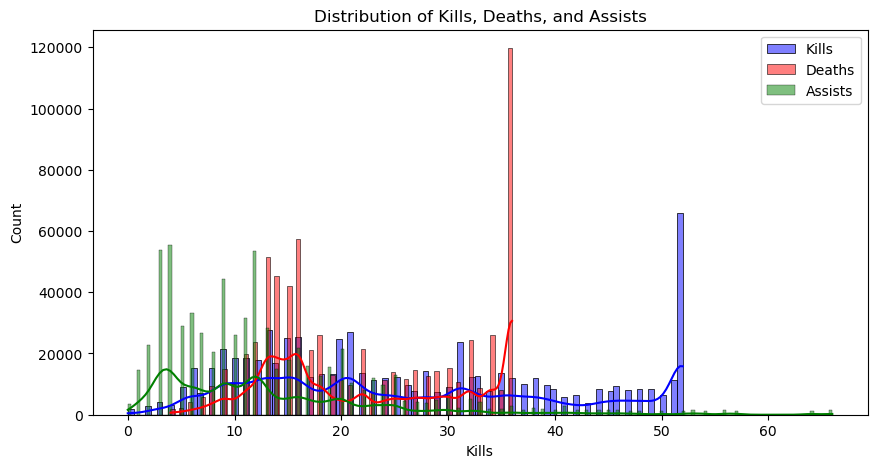

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Kills, Deaths, and Assists
plt.figure(figsize=(10, 5))
sns.histplot(player_level_data['Kills'], kde=True, color='blue', label='Kills')
sns.histplot(player_level_data['Deaths'], kde=True, color='red', label='Deaths')
sns.histplot(player_level_data['Assists'], kde=True, color='green', label='Assists')
plt.title("Distribution of Kills, Deaths, and Assists")
plt.legend()
plt.show()

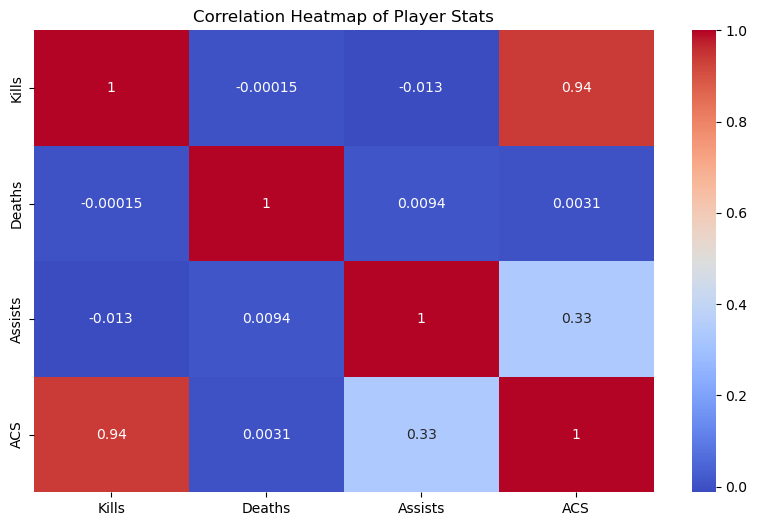

In [44]:
plt.figure(figsize=(10, 6))
sns.heatmap(player_level_data[['Kills', 'Deaths', 'Assists', 'ACS']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Player Stats")
plt.show()

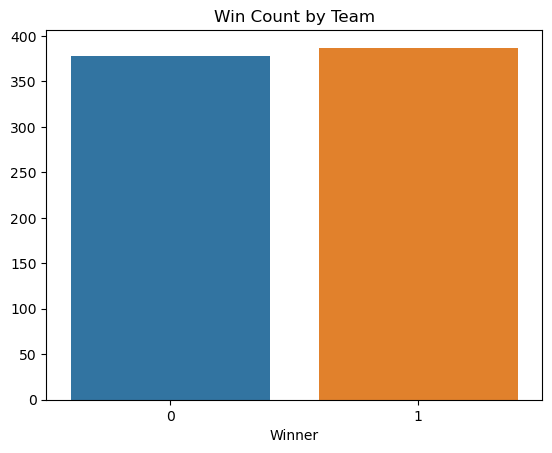

In [45]:
win_counts = match_data['Winner'].value_counts()
sns.barplot(x=win_counts.index, y=win_counts.values)
plt.title("Win Count by Team")
plt.show()

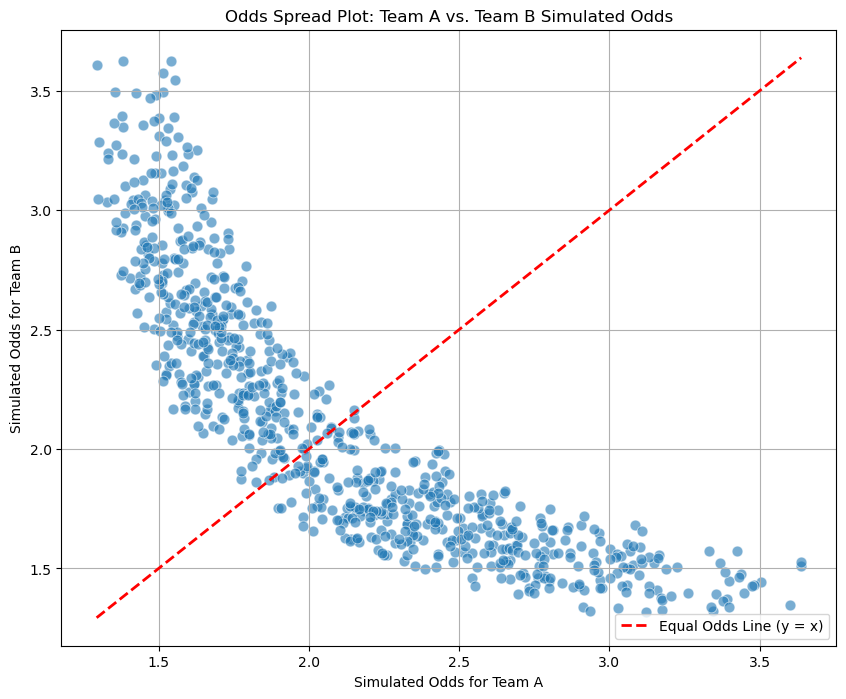

In [46]:
odds_a = simulated_odds['Simulated_Odds_A']
odds_b = simulated_odds['Simulated_Odds_B']

plt.figure(figsize=(10, 8))
sns.scatterplot(x=odds_a, y=odds_b, s=60, alpha=0.6)

# Add diagonal line (y = x) to show where odds are equal for both teams
plt.plot([min(odds_a), max(odds_a)], [min(odds_a), max(odds_a)], 'r--', lw=2, label="Equal Odds Line (y = x)")

# Customize plot
plt.title("Odds Spread Plot: Team A vs. Team B Simulated Odds")
plt.xlabel("Simulated Odds for Team A")
plt.ylabel("Simulated Odds for Team B")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\ASUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


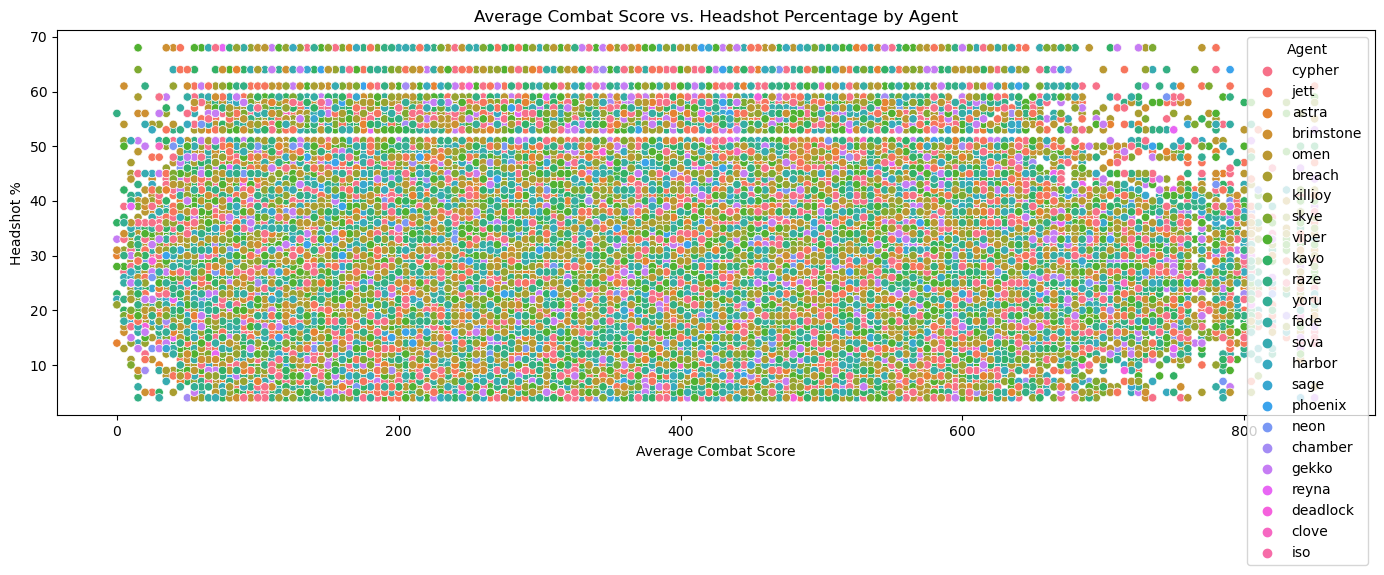

In [47]:
# Scatter Plot of ACS vs. Headshot Percentage
plt.figure(figsize=(17, 5))
sns.scatterplot(data=player_level_data, x='ACS', y='Headshot_Percentage', hue='Agent')
plt.title("Average Combat Score vs. Headshot Percentage by Agent")
plt.xlabel("Average Combat Score")
plt.ylabel("Headshot %")

plt.show()

# combin agg and create superdataset

In [48]:
# Import necessary libraries
import pandas as pd
from pymongo import MongoClient
from sklearn.preprocessing import MinMaxScaler

In [49]:


# Create a mapping from team names to IDs using the simulated odds data
team_id_mapping = dict(zip(simulated_odds['Team_A'], simulated_odds['Team_A_ID']))

# Map team names in match_data to IDs
match_data['Team_A_ID'] = match_data['Team_A'].map(team_id_mapping)
match_data['Team_B_ID'] = match_data['Team_B'].map(team_id_mapping)

# Drop rows where mapping failed
match_data = match_data.dropna(subset=['Team_A_ID', 'Team_B_ID'])

# Convert team IDs to integers
match_data['Team_A_ID'] = match_data['Team_A_ID'].astype(int)
match_data['Team_B_ID'] = match_data['Team_B_ID'].astype(int)

# Aggregate player-level data to team-level
player_aggregated = player_level_data.groupby(['Match ID', 'Team ID']).agg(
    Total_Kills=('Kills', 'sum'),
    Total_Deaths=('Deaths', 'sum'),
    Total_Assists=('Assists', 'sum'),
    Avg_ACS=('ACS', 'mean'),
    Avg_Headshot_Percentage=('Headshot_Percentage', 'mean'),
    Total_First_Bloods=('First_Bloods', 'sum')
).reset_index()

# Merge map performance data with match data
map_match_merged = pd.merge(match_data, map_performance, on="Match ID", how="left")

# Merge player aggregated data for Team_A
team_level_merged = pd.merge(
    map_match_merged,
    player_aggregated,
    left_on=["Match ID", "Team_A_ID"],
    right_on=["Match ID", "Team ID"],
    how="left"
)

team_level_merged.rename(columns={
    'Total_Kills': 'Team_A_Kills',
    'Total_Deaths': 'Team_A_Deaths',
    'Total_Assists': 'Team_A_Assists',
    'Avg_ACS': 'Team_A_ACS',
    'Avg_Headshot_Percentage': 'Team_A_Headshot_Percentage',
    'Total_First_Bloods': 'Team_A_First_Bloods'
}, inplace=True)

# Merge player aggregated data for Team_B
team_level_merged = pd.merge(
    team_level_merged,
    player_aggregated,
    left_on=["Match ID", "Team_B_ID"],
    right_on=["Match ID", "Team ID"],
    how="left"
)

team_level_merged.rename(columns={
    'Total_Kills': 'Team_B_Kills',
    'Total_Deaths': 'Team_B_Deaths',
    'Total_Assists': 'Team_B_Assists',
    'Avg_ACS': 'Team_B_ACS',
    'Avg_Headshot_Percentage': 'Team_B_Headshot_Percentage',
    'Total_First_Bloods': 'Team_B_First_Bloods'
}, inplace=True)

# Merge with simulated odds data
final_superdataset = pd.merge(team_level_merged, simulated_odds, on="Match ID", how="left")

# Select relevant columns
columns_to_keep = [
    'Match ID', 'Date', 'Map_x', 'Tournament_x', 'Team_A_ID_x', 'Team_B_ID_x',
    'Team_A_Kills', 'Team_A_Deaths', 'Team_A_Assists', 'Team_A_ACS', 'Team_A_Headshot_Percentage',
    'Team_A_First_Bloods', 'Team_B_Kills', 'Team_B_Deaths', 'Team_B_Assists',
    'Team_B_ACS', 'Team_B_Headshot_Percentage', 'Team_B_First_Bloods',
    'Implied_Prob_A', 'Implied_Prob_B', 'Simulated_Odds_A', 'Simulated_Odds_B', 'Winner'
]

# Keep only necessary columns and rename for clarity
cleaned_superdataset = final_superdataset[columns_to_keep]
cleaned_superdataset.rename(columns={
    'Map_x': 'Map',
    'Tournament_x': 'Tournament',
    'Team_A_ID_x': 'Team_A_ID',
    'Team_B_ID_x': 'Team_B_ID'
}, inplace=True)

# Remove rows with missing values (NaNs) from the cleaned_superdataset
cleaned_superdataset = cleaned_superdataset.dropna()

# Remove duplicate rows
cleaned_superdataset = cleaned_superdataset.drop_duplicates()

cleaned_superdataset

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21936\547889092.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_superdataset.rename(columns={


,Match ID,Date,Map,Tournament,Team_A_ID,Team_B_ID,Team_A_Kills,Team_A_Deaths,Team_A_Assists,Team_A_ACS,...,Team_B_Deaths,Team_B_Assists,Team_B_ACS,Team_B_Headshot_Percentage,Team_B_First_Bloods,Implied_Prob_A,Implied_Prob_B,Simulated_Odds_A,Simulated_Odds_B,Winner
0,247100,Group Stage,Fracture,Valorant Champions 2023,474,4915,469.0,276.0,234.0,450.769231,...,255.0,185.0,368.636364,25.909091,36.0,0.448778,0.551222,2.217374,1.721937,0
8,247101,Group Stage,Lotus,Valorant Champions 2023,8185,6961,303.0,287.0,95.0,292.083333,...,263.0,182.0,374.666667,27.733333,47.0,0.393940,0.606060,2.400236,1.811540,0
18,247087,Group Stage,Pearl,Valorant Champions 2023,1184,14,667.0,579.0,268.0,308.076923,...,249.0,247.0,300.384615,29.923077,50.0,0.449121,0.550879,2.325494,1.685509,0
34,247086,Group Stage,Ascent,Valorant Champions 2023,5248,11328,571.0,438.0,251.0,386.944444,...,506.0,295.0,322.142857,27.952381,103.0,0.444768,0.555232,2.414729,1.820764,0
50,247102,Group Stage,Bind,Valorant Champions 2023,4915,8185,450.0,418.0,315.0,357.352941,...,253.0,172.0,410.000000,23.272727,29.0,0.378092,0.621908,2.798530,1.448506,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22225,297253,Play-Ins,Icebox,Champions Tour 2024: Pacific Kickoff,5448,6199,250.0,196.0,162.0,300.909091,...,336.0,218.0,283.125000,29.562500,64.0,0.689273,0.310727,1.359484,2.948870,1
22236,297255,Play-Ins,Icebox,Champions Tour 2024: Pacific Kickoff,17,5448,633.0,441.0,305.0,436.388889,...,247.0,99.0,254.090909,28.090909,87.0,0.456637,0.543363,2.253684,2.006298,0
22247,297256,Playoffs,Split,Champions Tour 2024: Pacific Kickoff,14,624,295.0,294.0,158.0,340.000000,...,317.0,183.0,385.769231,28.769231,28.0,0.642620,0.357380,1.694927,2.779499,1
22255,297257,Playoffs,Bind,Champions Tour 2024: Pacific Kickoff,8185,17,933.0,786.0,401.0,333.382353,...,271.0,195.0,377.727273,35.454545,36.0,0.530019,0.469981,1.809977,1.930958,1


In [50]:
# # Convert the cleaned dataset to a dictionary format for MongoDB insertion
# cleaned_superdataset_records = cleaned_superdataset.to_dict(orient='records')
# db = client["main_db"]
# # Specify the target collection in MongoDB
# target_collection = db["superdataset1"]

# # Insert the cleaned data into the collection
# try:
#     # Drop the collection if it already exists (optional step to avoid duplication)
#     target_collection.drop()
#     # Insert records
#     target_collection.insert_many(cleaned_superdataset_records)
#     print(f"Inserted {len(cleaned_superdataset_records)} records into the 'superdataset' collection.")
# except Exception as e:
#     print("An error occurred while inserting data:", str(e))

Inserted 764 records into the 'superdataset' collection.


In [51]:
print("Match Data Missing Values:\n", cleaned_superdataset.isnull().sum())

Match Data Missing Values:
 Match ID                      0
Date                          0
Map                           0
Tournament                    0
Team_A_ID                     0
Team_B_ID                     0
Team_A_Kills                  0
Team_A_Deaths                 0
Team_A_Assists                0
Team_A_ACS                    0
Team_A_Headshot_Percentage    0
Team_A_First_Bloods           0
Team_B_Kills                  0
Team_B_Deaths                 0
Team_B_Assists                0
Team_B_ACS                    0
Team_B_Headshot_Percentage    0
Team_B_First_Bloods           0
Implied_Prob_A                0
Implied_Prob_B                0
Simulated_Odds_A              0
Simulated_Odds_B              0
Winner                        0
dtype: int64


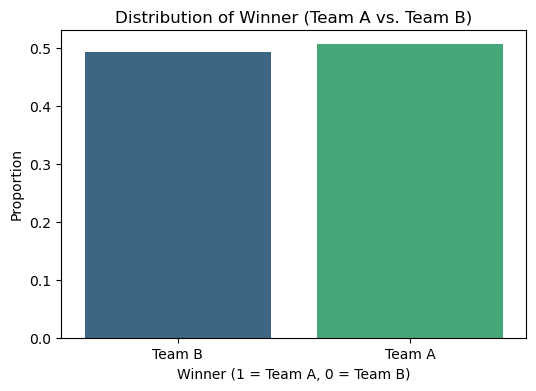

In [52]:
# Import necessary libraries
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["main_db"]

# Fetch the cleaned superdataset from MongoDB
cleaned_superdataset = pd.DataFrame(list(db["superdataset1"].find()))

# Drop the MongoDB-specific "_id" column if present
if "_id" in cleaned_superdataset.columns:
    cleaned_superdataset = cleaned_superdataset.drop(columns=["_id"])

# Step 1: Understand the data
eda_summary = cleaned_superdataset.describe(include='all')
missing_values = cleaned_superdataset.isnull().sum()


# Step 2: Analyze the target variable (Winner)
winner_distribution = cleaned_superdataset['Winner'].value_counts(normalize=True)

# Visualization for Winner distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=winner_distribution.index, y=winner_distribution.values, palette="viridis")
plt.title("Distribution of Winner (Team A vs. Team B)")
plt.xlabel("Winner (1 = Team A, 0 = Team B)")
plt.ylabel("Proportion")
plt.xticks([0, 1], labels=["Team B", "Team A"])
plt.show()
